In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# ASTROPY
import astropy.units as u
from astropy import constants as const
import astropy.coordinates as coord
from astropy.coordinates import SkyCoord
from astropy.coordinates import cartesian_to_spherical
# GALA
import gala.coordinates as gc
from gala.units import galactic
import gala.potential as galapot
# GALPY
import galpy.potential as galpy 
from galpy.orbit import Orbit
from galpy.potential import MovingObjectPotential,PlummerPotential,HernquistPotential
from galpy.potential import MiyamotoNagaiPotential,NFWPotential
# SCIPY
from scipy.interpolate import CubicSpline
from scipy import optimize
#Healpy
import healpy as hp
from healpy.newvisufunc import projview, newprojplot
#suavizar los mapas
fwhm2sigma = lambda fwhm: fwhm / np.sqrt(8*np.log(2))   


#### **Downloading data from a sky region using Gaia**

In [28]:
from astroquery.gaia import Gaia

query = """
SELECT TOP 1000
    source_id, ra, dec, parallax, pmra, pmdec, 
    radial_velocity, phot_g_mean_mag,
    phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax > 0
AND parallax_over_error > 10
"""

job = Gaia.launch_job(query)
results = job.get_results()
df = results.to_pandas()
print(df.head())

        source_id         ra       dec  parallax       pmra      pmdec  \
0   6223408420864  44.937649  0.188393  3.097849  46.522738 -30.799876   
1   7284264691456  45.062277  0.216004  6.227192  28.981164  49.350706   
2   7941395336832  44.972679  0.237833  4.569037  81.615457 -67.747252   
3  16355235668608  45.228942  0.380793  2.377022  32.263316  -1.128412   
4  31748398476672  44.948684  0.455275  0.913952   5.786338   4.471230   

   radial_velocity  phot_g_mean_mag  phot_bp_mean_mag  phot_rp_mean_mag  
0        -2.594310        13.932565         14.462439         13.249663  
1         1.720195        14.068443         14.881823         13.186197  
2        16.952108        15.159093         16.131428         14.181014  
3              NaN        17.238367         18.426327         16.165180  
4              NaN        15.906930         16.389004         15.271237  


In [29]:
print(f"Total de estrellas descargadas: {len(df)}")
print(f"\nForma del dataframe: {df.shape}")

Total de estrellas descargadas: 1000

Forma del dataframe: (1000, 10)


##### For a region toward the LMC

In [30]:
#From astroquery.gaia import Gaia

#query = """
#SELECT TOP 1000
 #   source_id, ra, dec, parallax, pmra, pmdec, 
  #  radial_velocity, phot_g_mean_mag
#FROM gaiadr3.gaia_source
#WHERE parallax > 0
#AND parallax_over_error > 10
#AND ra BETWEEN 80 AND 90
#AND dec BETWEEN -70 AND -60
#"""

job = Gaia.launch_job(query)
results = job.get_results()
df = results.to_pandas()
print(df.head())

       source_id         ra       dec  parallax       pmra      pmdec  \
0   828929527040  45.023620  0.068419  1.203095  13.952005 -10.803909   
1  1619203481984  44.951158  0.105312  1.717299  13.217856  12.767977   
2  4711579935744  44.894800  0.114031  1.039021  -7.708092 -24.447409   
3  5360119348480  44.959002  0.152369  2.708094  17.678658   0.622893   
4  8044474739968  44.928216  0.227490  1.377631  14.248811 -48.255309   

   radial_velocity  phot_g_mean_mag  phot_bp_mean_mag  phot_rp_mean_mag  
0              NaN        16.580168         17.225868         15.801358  
1              NaN        17.877853         19.220102         16.755497  
2        15.956611        14.277885         14.619662         13.765451  
3              NaN        18.442390         20.009190         17.268841  
4              NaN        17.710104         18.667549         16.746132  


In [31]:
#print(f"Total de estrellas descargadas hacia la LMC: {len(df)}")
#print(f"\nForma del dataframe: {df.shape}")

In [32]:
# # Check missing values per column 
print("Valores faltantes por columna:")
print(df.isnull().sum())
print(f"\nPorcentaje de NaN en radial_velocity: {df['radial_velocity'].isnull().sum()/len(df)*100:.1f}%")

Valores faltantes por columna:
source_id             0
ra                    0
dec                   0
parallax              0
pmra                  0
pmdec                 0
radial_velocity     706
phot_g_mean_mag       0
phot_bp_mean_mag      5
phot_rp_mean_mag      5
dtype: int64

Porcentaje de NaN en radial_velocity: 70.6%


#### *Sky region covered*

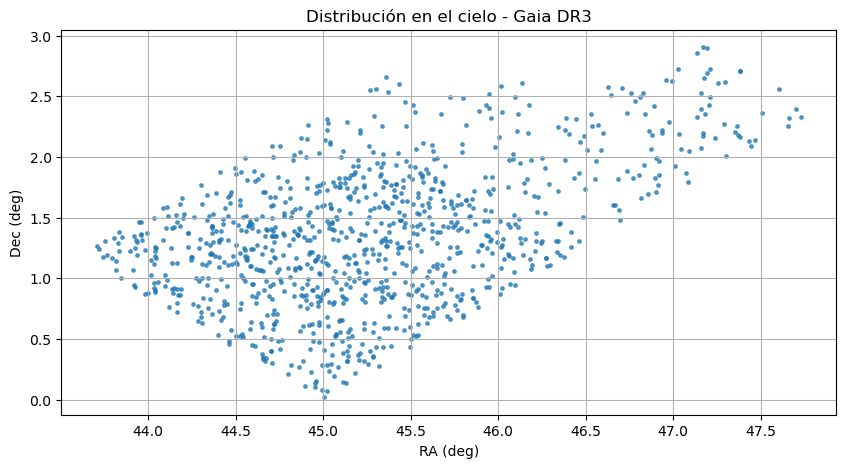

In [33]:
plt.figure(figsize=(10, 5))
plt.scatter(df['ra'], df['dec'], s=6, alpha=0.7)
plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.title('Distribución en el cielo - Gaia DR3')
plt.grid(True)
plt.show()

##### * Duplicates: Gaia may have the same star registered more than once due to catalog errors.
##### * Parallax $> 0$: The parallax is the angular displacement of a star in the sky due to Earth's motion around the Sun. By geometric definition it cannot be $< 0$. Additionally, Gaia measurements have uncertainties, and for very distant stars the parallax is so small that instrumental noise can produce negative values.
##### * Magnitude outliers: Extremely bright or faint stars may have unreliable measurements. A 1-99% percentile filter removes the most extreme cases.
##### * NaN in radial_velocity: This is an instrumental limitation of Gaia DR3, not an error. Radial velocity requires spectroscopy and is not available for all stars.

In [34]:
# 1. Eliminar duplicados
df_clean = df.drop_duplicates(subset='source_id')
print(f"Después de eliminar duplicados: {len(df_clean)}")

# 2. Eliminar parallax negativos o cero (no tienen sentido físico)
df_clean = df_clean[df_clean['parallax'] > 0]
print(f"Después de filtrar parallax: {len(df_clean)}")

# 3. Eliminar outliers en magnitud
#quantile funcion de Pandas para calcular el percentil que le pido
q_low = df_clean['phot_g_mean_mag'].quantile(0.01)
q_high = df_clean['phot_g_mean_mag'].quantile(0.99)
df_clean = df_clean[(df_clean['phot_g_mean_mag'] >= q_low) & 
                     (df_clean['phot_g_mean_mag'] <= q_high)]
print(f"Después de filtrar outliers en magnitud: {len(df_clean)}")

# 4. Documentar los NaN en radial_velocity - no los eliminamos
print(f"\nNaN en radial_velocity: {df_clean['radial_velocity'].isnull().sum()} ({df_clean['radial_velocity'].isnull().sum()/len(df_clean)*100:.1f}%)")
print("Nota: radial_velocity no disponible para todas las estrellas en Gaia DR3")

Después de eliminar duplicados: 1000
Después de filtrar parallax: 1000
Después de filtrar outliers en magnitud: 980

NaN en radial_velocity: 695 (70.9%)
Nota: radial_velocity no disponible para todas las estrellas en Gaia DR3


In [35]:
print("="*40)
print("RESUMEN DE LIMPIEZA DE DATOS")
print("="*40)
print(f"Datos originales:        {len(df)} estrellas")
print(f"Después de limpieza:     {len(df_clean)} estrellas")
print(f"Eliminadas:              {len(df) - len(df_clean)} estrellas")
print(f"Columnas con NaN:")
print(f"  radial_velocity:       {df_clean['radial_velocity'].isnull().sum()} ({df_clean['radial_velocity'].isnull().sum()/len(df_clean)*100:.1f}%)")
print(f"  → Limitación instrumental de Gaia DR3, no un error")
print("="*40)

RESUMEN DE LIMPIEZA DE DATOS
Datos originales:        1000 estrellas
Después de limpieza:     980 estrellas
Eliminadas:              20 estrellas
Columnas con NaN:
  radial_velocity:       695 (70.9%)
  → Limitación instrumental de Gaia DR3, no un error


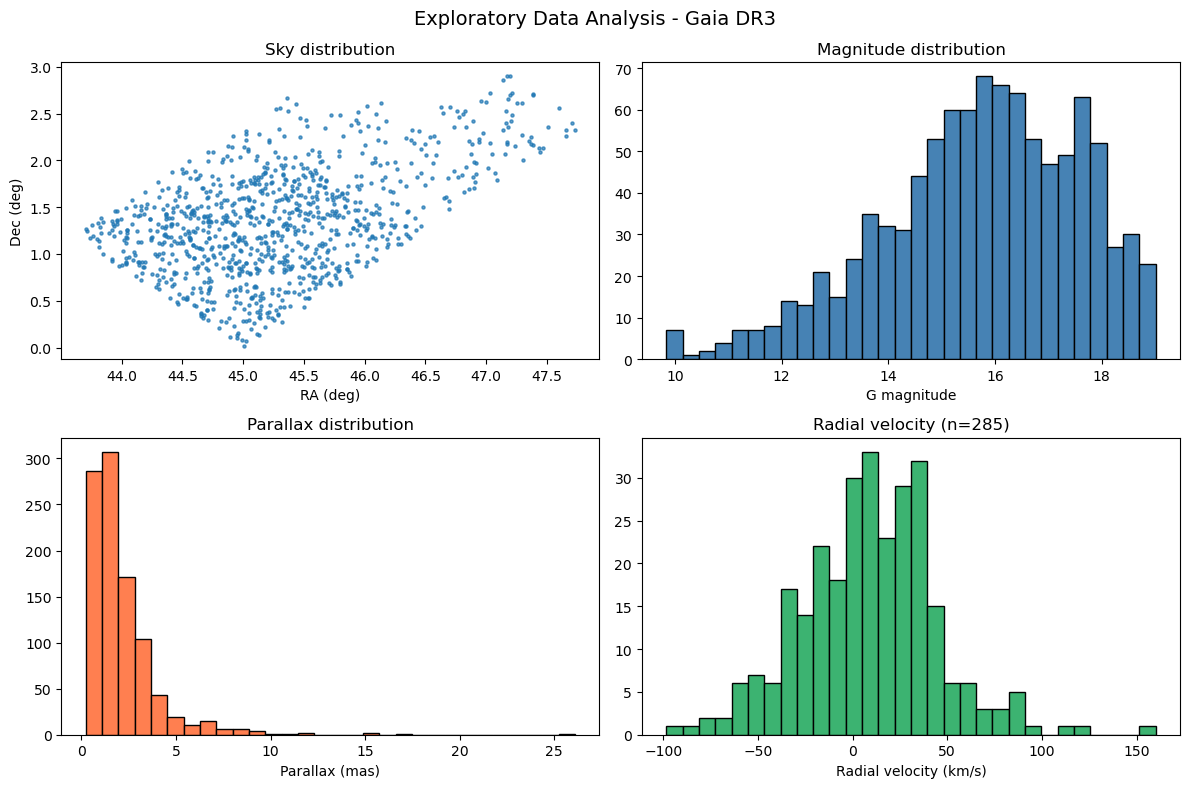

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Exploratory Data Analysis - Gaia DR3', fontsize=14)

# 1. Distribución en el cielo
axes[0,0].scatter(df_clean['ra'], df_clean['dec'], s=5, alpha=0.7)
axes[0,0].set_xlabel('RA (deg)')
axes[0,0].set_ylabel('Dec (deg)')
axes[0,0].set_title('Sky distribution')

# 2. Histograma de magnitud
axes[0,1].hist(df_clean['phot_g_mean_mag'], bins=30, color='steelblue', edgecolor='black')
axes[0,1].set_xlabel('G magnitude')
axes[0,1].set_title('Magnitude distribution')

# 3. Histograma de paralaje
axes[1,0].hist(df_clean['parallax'], bins=30, color='coral', edgecolor='black')
axes[1,0].set_xlabel('Parallax (mas)')
axes[1,0].set_title('Parallax distribution')

# 4. Velocidad radial (solo las que tienen)
df_rv = df_clean.dropna(subset=['radial_velocity'])
axes[1,1].hist(df_rv['radial_velocity'], bins=30, color='mediumseagreen', edgecolor='black')
axes[1,1].set_xlabel('Radial velocity (km/s)')
axes[1,1].set_title(f'Radial velocity (n={len(df_rv)})')

plt.savefig('eda_4panels.pdf')
plt.savefig('eda_4panels.png')
plt.tight_layout()
plt.show()

##### Parallax distribution: There are many more distant stars than nearby ones 
in any direction of the sky, which explains the histogram concentrated 
at small parallax values with a long tail toward larger values.

##### Magnitude histogram: Few very bright stars (mag 10-12) — rare and nearby; 
many stars of intermediate magnitude (14-17) — the bulk of the catalog; 
fewer very faint stars (>18) — approaching Gaia's detection limit.

Note: In astronomy the magnitude scale is inverted — 
lower values correspond to brighter stars.

## **Some Derived Variables**

##### Distance from parallax: $d \text{ (pc)} = 1/\pi \text{ (arcsec)}$
##### Gaia provides parallax in mas, so: $1 \text{ arcsec} = 1000 \text{ mas}$, 
therefore $d \text{ (pc)} = 1000/\pi \text{ (mas)}$

In [37]:
#distancia en parsec 
df_clean['distance_pc'] = 1000 / df_clean['parallax']  # parallax en mas, distancia en pc
#print(df_clean[['source_id', 'parallax', 'distance_pc']].head())



#################### distancia en kpc
df_clean['distance_kpc'] = df_clean['distance_pc'] / 1000  # distancia en kpc
print(df_clean[['source_id', 'parallax', 'distance_kpc']].head())

################## modulo de la distancia 
df_clean['distance_modulus'] = 5 * np.log10(df_clean['distance_pc']) - 5
print(df_clean[['source_id', 'distance_pc', 'distance_kpc', 'distance_modulus']].head())


       source_id  parallax  distance_kpc
0   828929527040  1.203095      0.831190
1  1619203481984  1.717299      0.582310
2  4711579935744  1.039021      0.962444
3  5360119348480  2.708094      0.369263
4  8044474739968  1.377631      0.725884
       source_id  distance_pc  distance_kpc  distance_modulus
0   828929527040   831.189790      0.831190          9.598501
1  1619203481984   582.309679      0.582310          8.825770
2  4711579935744   962.444351      0.962444          9.916878
3  5360119348480   369.263362      0.369263          7.836681
4  8044474739968   725.883815      0.725884          9.304336


In [38]:
df_clean 

,source_id,ra,dec,parallax,pmra,pmdec,radial_velocity,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,distance_pc,distance_kpc,distance_modulus
0,828929527040,45.023620,0.068419,1.203095,13.952005,-10.803909,NaN,16.580168,17.225868,15.801358,831.189790,0.831190,9.598501
1,1619203481984,44.951158,0.105312,1.717299,13.217856,12.767977,NaN,17.877853,19.220102,16.755497,582.309679,0.582310,8.825770
2,4711579935744,44.894800,0.114031,1.039021,-7.708092,-24.447409,15.956611,14.277885,14.619662,13.765451,962.444351,0.962444,9.916878
3,5360119348480,44.959002,0.152369,2.708094,17.678658,0.622893,NaN,18.442390,20.009190,17.268841,369.263362,0.369263,7.836681
4,8044474739968,44.928216,0.227490,1.377631,14.248811,-48.255309,NaN,17.710104,18.667549,16.746132,725.883815,0.725884,9.304336
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,946610792659840,45.303443,2.555852,1.734205,14.783570,-16.393580,NaN,17.518192,18.655315,16.492149,576.632952,0.576633,8.804497
996,947233562300672,45.267411,2.551178,4.453413,18.236200,-34.576274,NaN,16.369829,17.229179,14.664088,224.546900,0.224547,6.756535
997,949879262711680,45.360113,2.662138,0.503589,1.225997,-9.077408,NaN,15.421311,15.756099,14.902057,1985.744926,1.985745,11.489617
998,951769048342272,45.726662,2.490468,1.757243,30.535767,-12.325628,NaN,15.003165,15.526303,14.321295,569.073274,0.569073,8.775841


### **Galactic coodinates**

In [39]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# Convertir ra, dec → coordenadas galácticas
coords = SkyCoord(ra=df_clean['ra'].values * u.degree,
                  dec=df_clean['dec'].values * u.degree,
                  frame='icrs')

galactic = coords.galactic


#grados
df_clean['l'] = galactic.l.deg  # longitud galáctica
df_clean['b'] = galactic.b.deg  # latitud galáctica
#radianes 
df_clean['phi'] = galactic.l.rad  # longitud galáctica en radianes
df_clean['theta'] = galactic.b.rad  # latitud galáctica en radianes
# colatitud theta desde el polo norte galáctico hasta el plano galáctico (b=0)
df_clean['theta_deg'] = 90 - galactic.b.deg  # colatitud en grados   

print(df_clean[['ra', 'dec', 'l', 'b', 'theta', 'theta_deg','phi']].head())

          ra       dec           l          b     theta   theta_deg       phi
0  45.023620  0.068419  176.911311 -48.838160 -0.852387  138.838160  3.087685
1  44.951158  0.105312  176.794479 -48.864651 -0.852849  138.864651  3.085646
2  44.894800  0.114031  176.725343 -48.899077 -0.853450  138.899077  3.084439
3  44.959002  0.152369  176.751388 -48.826289 -0.852179  138.826289  3.084894
4  44.928216  0.227490  176.636956 -48.796088 -0.851652  138.796088  3.082896


#### *Transverse Velocity*

##### The transverse velocity is the component of the stellar velocity 
perpendicular to the line of sight. While radial velocity is measured 
via the Doppler effect, the transverse velocity is derived from the 
proper motion (pmra, pmdec) and the distance:

$$v_t = 4.74 \cdot \mu_{total} \cdot d \text{ (kpc)}$$

where $\mu_{total} = \sqrt{\mu_{ra}^2 + \mu_{dec}^2}$ is the total 
proper motion in mas/yr and 4.74 is the conversion factor from 
(mas/yr · kpc) to km/s.

In [40]:
### Velocidad tramsversal

cte=4.74   # conversion factor: (km/s) / (mas/yr * kpc)

df_clean[ 'mu_total']= np.sqrt(df_clean['pmra']**2 + df_clean['pmdec']**2)  # mas/yr
df_clean[ 'v_t']= cte * df_clean['mu_total'] * df_clean['distance_kpc']  # km/s

print(df_clean[['source_id', 'pmra', 'pmdec', 'mu_total', 'distance_kpc', 'v_t']].head())

       source_id       pmra      pmdec   mu_total  distance_kpc         v_t
0   828929527040  13.952005 -10.803909  17.646045      0.831190   69.522586
1  1619203481984  13.217856  12.767977  18.377512      0.582310   50.724652
2  4711579935744  -7.708092 -24.447409  25.633777      0.962444  116.940936
3  5360119348480  17.678658   0.622893  17.689628      0.369263   30.962303
4  8044474739968  14.248811 -48.255309  50.315043      0.725884  173.118428


### **HR -  Diagram** 

#### BP (Blue Photometer)
#### RP(Red Photometer)

Color se calcula BP-RP. 
Las estrellas azules/calientes tienen un BR-RP pequeño. Mientras que las estrellas rojas/frías, grande.

#### * BP and RP bands are used because they are narrower and more separated 
than the G band, so their difference better captures the stellar temperature.

#### * *In Gaia*, BP-RP is the standard color index precisely because it 
maximizes the contrast between hot and cool stars.

#### * We use absolute magnitude instead of apparent magnitude because the 
latter depends on distance — a very luminous but distant star may appear 
fainter than a intrinsically faint but nearby one.
#### * Absolute magnitude corrects for this by placing all stars at the 
same reference distance (10 pc).

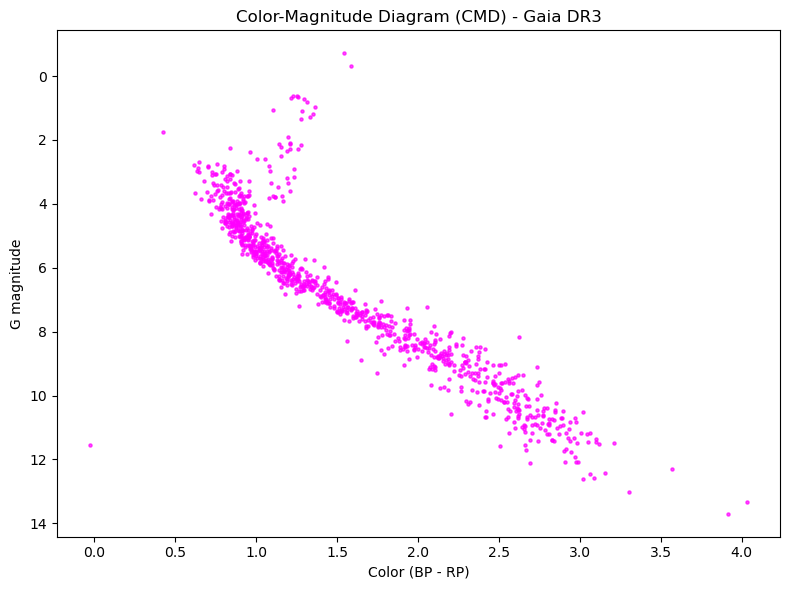

In [41]:
df_clean['color_BP']=df_clean['phot_bp_mean_mag'] - df_clean['phot_rp_mean_mag']

#absolut magnitude
df_clean['M_G'] = df_clean['phot_g_mean_mag'] - df_clean['distance_modulus']

# Color Magnitude Diagram (CMD)
plt.figure(figsize=(8, 6))
plt.scatter(df_clean['color_BP'], df_clean['M_G'], c='magenta', s=5, alpha=0.7,label='stars in Gaia DR3')
plt.gca().invert_yaxis()  # Invertir eje y para que las estrellas más brillantes estén arriba
plt.xlabel('Color (BP - RP)')
plt.ylabel('G magnitude')
plt.title('Color-Magnitude Diagram (CMD) - Gaia DR3')

plt.savefig('cmd_gaia_dr3.pdf')
plt.savefig('cmd_gaia_dr3.png')
plt.tight_layout()
plt.show()

#### The points in the lower left region (BP-RP < 0.5, M_G > 10) could be white dwarf candidates or parallax outliers with unreliable distance estimates. Since ```parallax_error``` was not included in this query, a definitive classification is not possible here.
#### Future work could investigate this by adding ```parallax_error``` to the selection and filtering by parallax_over_error. 


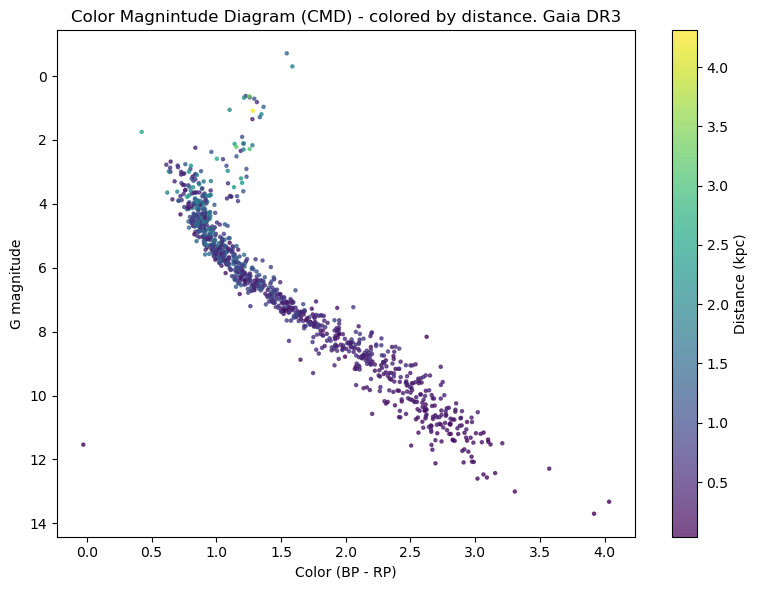

In [42]:
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    df_clean['color_BP'],
    df_clean['M_G'],
    c=df_clean['distance_kpc'],  # color por distancia
    cmap='viridis',
    s=5,
    alpha=0.7
)

plt.gca().invert_yaxis()

cbar = plt.colorbar(sc)
cbar.set_label('Distance (kpc)')

plt.xlabel('Color (BP - RP)')
plt.ylabel('G magnitude')
plt.title('Color Magnintude Diagram (CMD) - colored by distance. Gaia DR3')

plt.tight_layout()
plt.savefig('cmd_distance_color.png', dpi=300)
plt.savefig('cmd_distance_color.pdf', dpi=300)
plt.show()